In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker

In [12]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True, 
    'xtick.top': True,
    'ytick.right': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'grid.alpha': 0.6
})

In [13]:
from menedpy import Problem, solve, generate_mesh, Domain

import matplotlib.pyplot as plt
import matplotlib.tri as mtri

domain = Domain(lower_boundary=lambda x: max(0.0, 0.2 * np.sin(2.0 * np.pi * x)))
mesh = generate_mesh(domain=domain, nx=20, ny=20)

problem = Problem(domain=domain, final_time=1.0)
times, solutions = solve(problem, mesh, n_steps=int(1.0/0.01))

# Figura 1: Condiciones iniciales

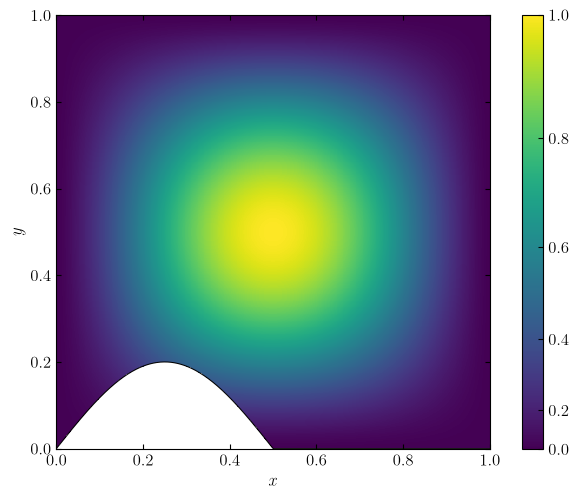

In [14]:
n = 500
x = np.linspace(*domain.x_range, n)
y = np.linspace(*domain.x_range, n)
X, Y = np.meshgrid(x, y)

# Function to paint
U = problem.source(X, Y, 0.0)

# Region Ω:
mask = (Y > np.vectorize(domain.lower_boundary)(X)) * (Y < np.vectorize(domain.upper_boundary)(X))

U_masked = np.where(mask, U, np.nan)

fig, ax = plt.subplots()

im = plt.pcolormesh(
    X, Y, U_masked,
    cmap='viridis',
    rasterized=True,
    norm=matplotlib.colors.PowerNorm(gamma=1.5, vmax=1),
)

upper = np.vectorize(domain.upper_boundary)(x)
lower = np.vectorize(domain.lower_boundary)(x)

plt.plot(x, upper, 'k', linewidth=0.75)
plt.plot(x, lower, 'k', linewidth=0.75)

plt.grid(False)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

plt.tight_layout(pad=0.15)
plt.xticks(np.arange(0, 1.1, 0.2))


plt.colorbar(mappable=im)
ax.set_aspect('equal')
plt.tight_layout(pad=0.0)

plt.savefig("cond_inic.pdf", dpi=300)

# Figura 2: Triangulación

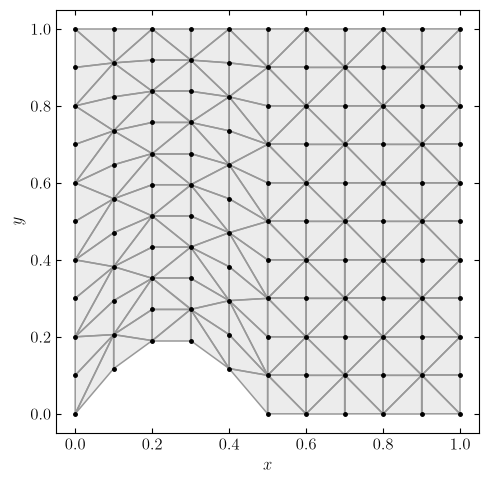

In [15]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

test_mesh = generate_mesh(domain=domain)
# test_mesh = mesh


fig, ax = plt.subplots()

plt.grid(False)

for tri in test_mesh.triangles:
    vertices = test_mesh.points[tri]

    ax.fill(
        vertices[:, 0],
        vertices[:, 1],
        facecolor=to_rgba("black", 0.075),
        edgecolor=0.6*np.array([1,1,1]),
        linewidth=1.1
    )

ax.plot(test_mesh.points[:, 0], test_mesh.points[:, 1], "o", markersize=2.5, color="black")

ax.set_aspect("equal")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

plt.tight_layout(pad=0.5)
plt.savefig("triangulacion.pdf", dpi=300)

# Figura 3: Solución

IndexError: index 20 is out of bounds for axis 0 with size 11

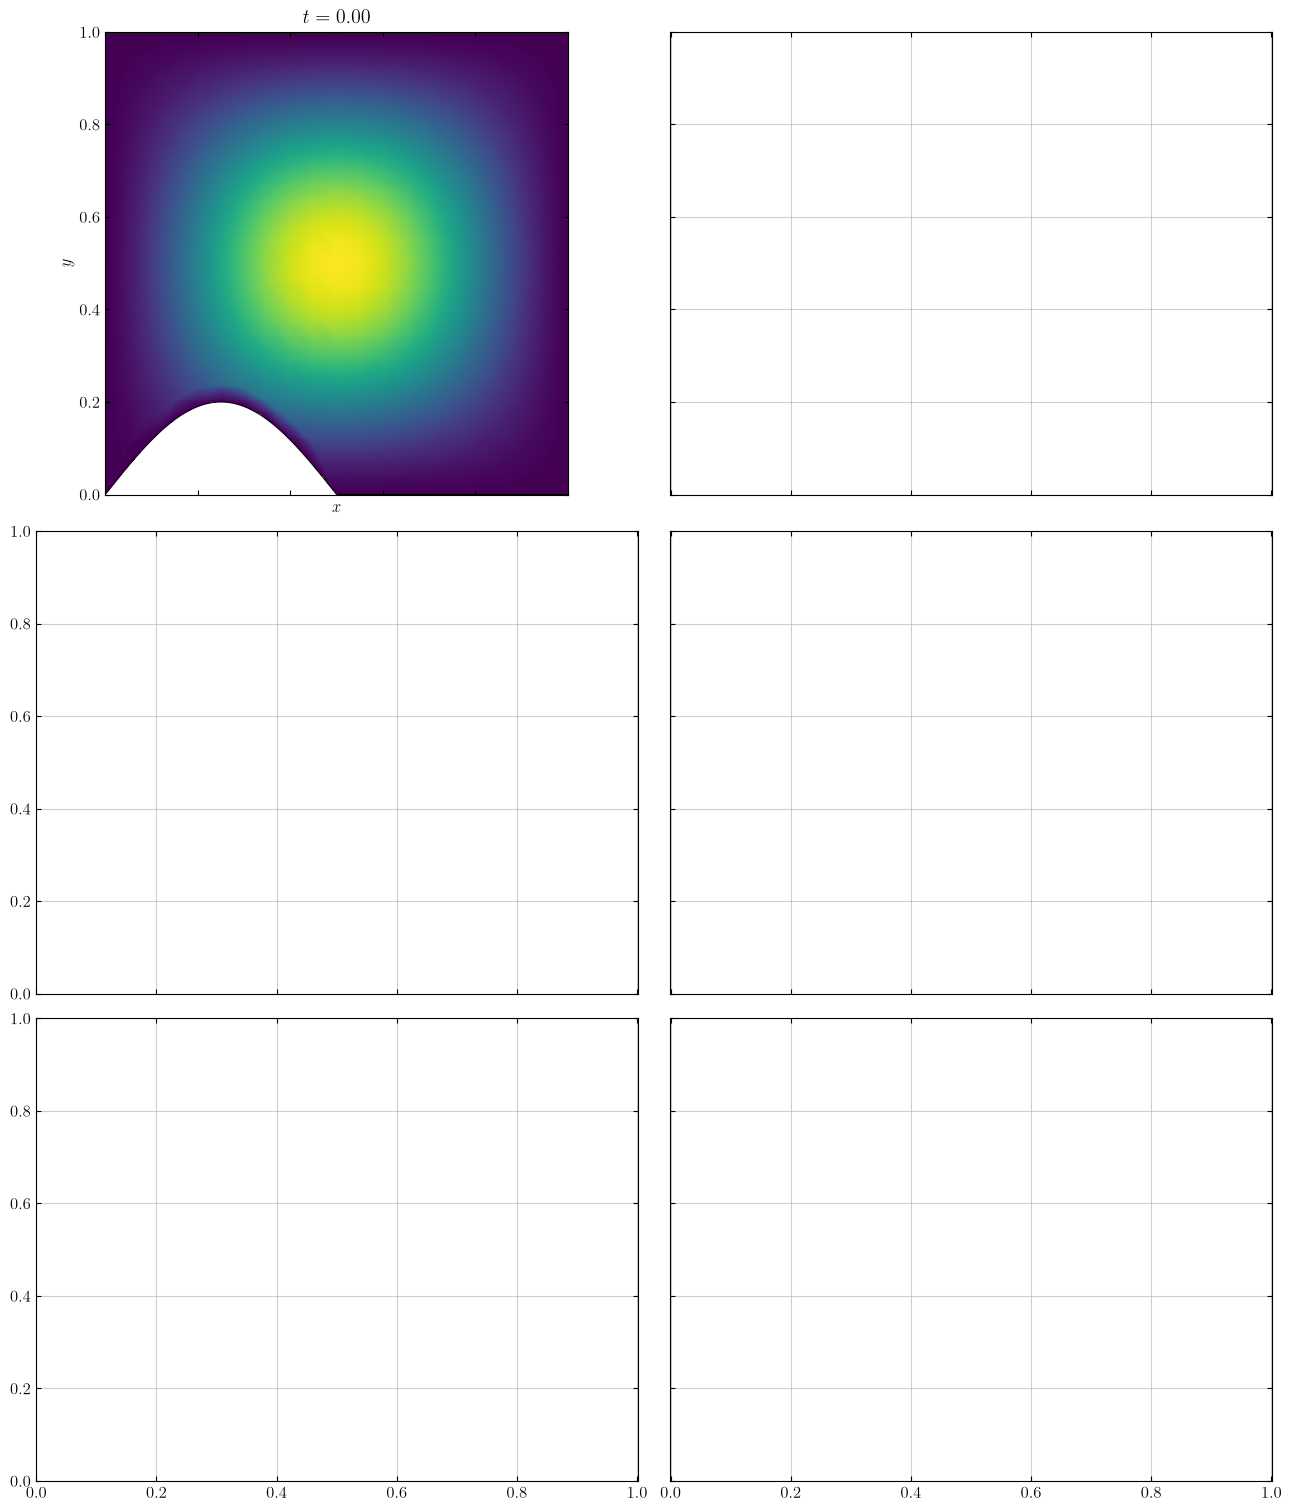

In [16]:
from menedpy.time_stepping import explicit_euler_step, implicit_euler_step, crank_nicolson_step
from menedpy.systems import super_ostrowski

domain = Domain()
mesh = generate_mesh(domain=domain, nx=20, ny=20)
problem = Problem(domain=domain, final_time=0.01)

for time_stepper, name in zip(
    [implicit_euler_step, crank_nicolson_step],
    ["euler_implicit", "crank_nicolson"]
):

    times, solutions = solve(problem=problem, mesh=mesh, n_steps=int(0.01/(0.1/1000)), time_stepper=time_stepper, nonlinear_solver=super_ostrowski)


    n = 500
    x = np.linspace(0, 1, n)
    y = np.linspace(0, 1, n)
    X, Y = np.meshgrid(x, y)

    upper = np.vectorize(domain.upper_boundary)(x)
    lower = np.vectorize(domain.lower_boundary)(x)

    FIG, AX = plt.subplots(3,2, figsize=(6.4*2,15), sharex=True, sharey=True, constrained_layout=True)

    for t, ax in zip(np.linspace(0,problem.final_time,6), AX.flatten()):
        i = int(10000*t)

        triangulation = mtri.Triangulation(mesh.points[:, 0], mesh.points[:, 1], mesh.triangles)
        interpolator = mtri.LinearTriInterpolator(triangulation, solutions[i])
        U = np.ma.filled(interpolator(X, Y), np.nan)
        U_masked = np.where(mask, U, np.nan)

        im = ax.pcolormesh(
            X, Y, U_masked,
            cmap="viridis",
            rasterized=True,
            norm=matplotlib.colors.PowerNorm(gamma=1.5)
        )

        ax.set_title(f"$t={t:.2f}$")
        ax.grid(False)
        
        ax.plot(x, upper, 'k', linewidth=0.75)
        ax.plot(x, lower, 'k', linewidth=0.75)
        
        ax.set_aspect("equal")

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    plt.xticks(np.arange(0, 1.1, 0.2))

    cbar = FIG.colorbar(
        im,
        ax=AX,              # or ax=AX.ravel()
        location="right",
        # shrink=0.95,
        pad=0.02,
        aspect=40,
    )

    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, -2))  # Force ×10^-2
    cbar.formatter = formatter
    cbar.update_ticks()

    plt.savefig("solucion.pdf", dpi=300)
    plt.show()

# Figura 4: Comparativa

In [17]:
# Veces que se ejecuta:
num = 50

## Euler implícito

In [22]:
from menedpy.time_stepping import implicit_euler_step, crank_nicolson_step
from menedpy.systems import newton, KLAM, super_ostrowski

domain = Domain()
mesh = generate_mesh(domain=domain)

problem = Problem(domain=domain, final_time=1.0)

n_steps = int(1 / 0.01)

newton_times = []
klam_times = []
super_ostrowski_times = []


for _ in range(num):
    times1, solutions1, info1 = solve(problem, mesh, n_steps=n_steps, time_stepper=implicit_euler_step, nonlinear_solver=newton, return_info=True)
    times2, solutions2, info2 = solve(problem, mesh, n_steps=n_steps, time_stepper=implicit_euler_step, nonlinear_solver=KLAM, return_info=True)
    times3, solutions3, info3 = solve(problem, mesh, n_steps=n_steps, time_stepper=implicit_euler_step, nonlinear_solver=super_ostrowski, return_info=True)

    newton_times.append([i["nss_time"] for i in info1])
    klam_times.append([i["nss_time"] for i in info2])
    super_ostrowski_times.append([i["nss_time"] for i in info3])

newton_iter = [len(i["errors"]) for i in info1]
klam_iter = [len(i["errors"]) for i in info2]
super_ostrowski_iter = [len(i["errors"]) for i in info3]

Tiempo total Newton: 2.746219031952787
Tiempo total KLAM5S: 3.90245245400467
Tiempo total ARJ8S: 6.113314676024021


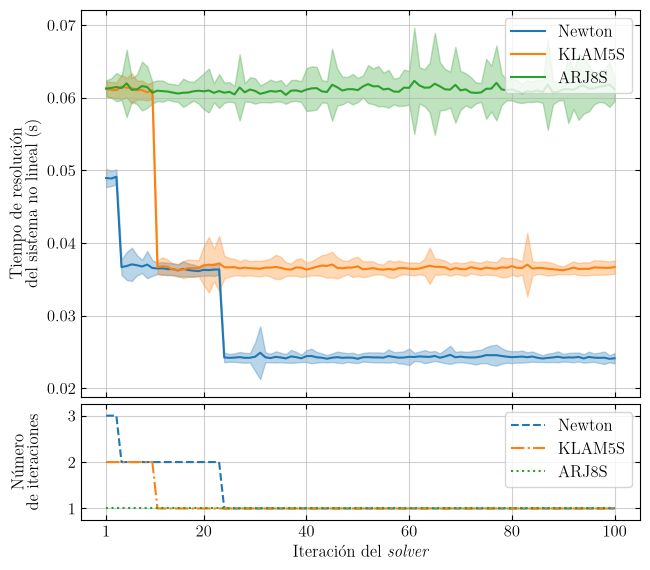

In [24]:
fig, ax = plt.subplots(
    2,1,
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1.2]},
    figsize=(6.4, 5.6)
)  

iterations = range(1, len(newton_iter) + 1)

# Subfigure 1
for x, name, c in zip(
    [newton_times, klam_times, super_ostrowski_times],
    ["Newton", "KLAM5S", "ARJ8S"],
    ["tab:blue", "tab:orange", "tab:green"]
):

    sd = np.std(x, axis=0)
    mean = np.mean(x, axis=0)

    print(f"Tiempo total {name}: {np.sum(mean)}")
    
    ax[0].plot(iterations, mean, color=c, linewidth=1.5, label=name)

    ax[0].fill_between(
        iterations,
        mean - sd,
        mean + sd,
        color=c,
        alpha=0.3
    )

ax[0].legend(loc="upper right")
ax[0].set_ylabel("Tiempo de resolución \n del sistema no lineal (s)")

# Subfigure 2
ax[1].plot(iterations, newton_iter, '--', label="Newton")
ax[1].plot(iterations, klam_iter, '-.', label="KLAM5S")
ax[1].plot(iterations, super_ostrowski_iter, ':', label="ARJ8S")

ax[1].legend(loc="upper right")

ax[1].set_xticks([1, 20, 40, 60, 80, 100])
ax[1].set_yticks([1,2,3])
ax[1].set_ylim([0.75, 3.25])


ax[1].set_xlabel(r"Iteración del \textit{solver}")
ax[1].set_ylabel("Número \n de iteraciones")

fig.align_ylabels(ax)

plt.tight_layout(pad=0.3)
plt.savefig("nonlinear_solver_euler_implicito.pdf")

## Crank-Nicolson

In [20]:
newton_times = []
klam_times = []
super_ostrowski_times = []


for _ in range(num):
    times1, solutions1, info1 = solve(problem, mesh, n_steps=n_steps, time_stepper=crank_nicolson_step, nonlinear_solver=newton, return_info=True)
    times2, solutions2, info2 = solve(problem, mesh, n_steps=n_steps, time_stepper=crank_nicolson_step, nonlinear_solver=KLAM, return_info=True)
    times3, solutions3, info3 = solve(problem, mesh, n_steps=n_steps, time_stepper=crank_nicolson_step, nonlinear_solver=super_ostrowski, return_info=True)

    newton_times.append([i["nss_time"] for i in info1])
    klam_times.append([i["nss_time"] for i in info2])
    super_ostrowski_times.append([i["nss_time"] for i in info3])

newton_iter = [len(i["errors"]) for i in info1]
klam_iter = [len(i["errors"]) for i in info2]
super_ostrowski_iter = [len(i["errors"]) for i in info3]

Tiempo total Newton: 3.669805773980916
Tiempo total KLAM5S: 3.878044629903743
Tiempo total ARJ8S: 6.074425666006283


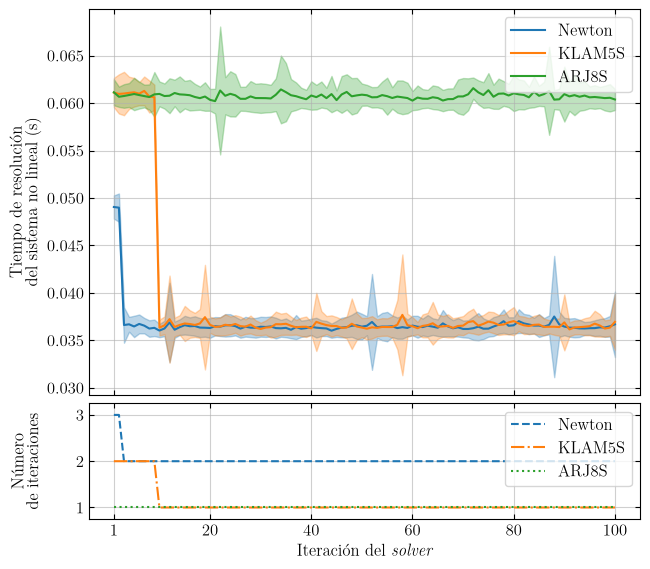

In [21]:
fig, ax = plt.subplots(
    2,1,
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1.2]},
    figsize=(6.4, 5.6)
)  

iterations = range(1, len(newton_iter) + 1)

# Subfigure 1
for x, name, c in zip(
    [newton_times, klam_times, super_ostrowski_times],
    ["Newton", "KLAM5S", "ARJ8S"],
    ["tab:blue", "tab:orange", "tab:green"]
):

    sd = np.std(x, axis=0)
    mean = np.mean(x, axis=0)

    print(f"Tiempo total {name}: {np.sum(mean)}")
    
    ax[0].plot(iterations, mean, color=c, linewidth=1.5, label=name)

    ax[0].fill_between(
        iterations,
        mean - sd,
        mean + sd,
        color=c,
        alpha=0.3
    )

ax[0].legend(loc="upper right")
ax[0].set_ylabel("Tiempo de resolución \n del sistema no lineal (s)")

# Subfigure 2
ax[1].plot(iterations, newton_iter, '--', label="Newton")
ax[1].plot(iterations, klam_iter, '-.', label="KLAM5S")
ax[1].plot(iterations, super_ostrowski_iter, ':', label="ARJ8S")

ax[1].legend(loc="upper right")

ax[1].set_xticks([1, 20, 40, 60, 80, 100])
ax[1].set_yticks([1,2,3])
ax[1].set_ylim([0.75, 3.25])

ax[1].set_xlabel(r"Iteración del \textit{solver}")
ax[1].set_ylabel("Número \n de iteraciones")

fig.align_ylabels(ax)

plt.tight_layout(pad=0.3)
plt.savefig("nonlinear_solver_crank_nicolson.pdf")

# Generar tablas a partir de listas

In [ ]:
def make_table(the_list, name, cols):
    text = r"\texttt{" + name + " = }" + "\n"+r"\begin{tabular}{" + "c"*cols + "}\n"

    for i, num in enumerate(the_list, start=1):
        text += f" {num}, & "
        if i % cols == 0:
            text = text[:-2]
            text += r"\\"+"\n"

    text += r"\end{tabular}"
    return text

def make_table_points2(the_list, name, cols):
    text = r"\texttt{" + name + " = }" + "\n"+r"\begin{tabular}{" + "c"*cols + "}\n"

    for i, num in enumerate(the_list, start=1):
        text += f" ({num[0]:.5}, {num[1]:.5}), & "
        if i % cols == 0:
            text = text[:-2]
            text += r"\\"+"\n"

    text += r"\end{tabular}"
    return text

def make_table_points3(the_list, name, cols):
    text = r"\texttt{" + name + " = }" + "\n"+r"\begin{tabular}{" + "c"*cols + "}\n"

    for i, num in enumerate(the_list, start=1):
        text += f" ({num[0]}, {num[1]}, {num[2]}), & "
        if i % cols == 0:
            text = text[:-2]
            text += r"\\"+"\n"

    text += r"\end{tabular}"
    return text

In [ ]:
print(make_table(test_mesh.boundary_nodes, r"test\_mesh.boundary\_nodes", 6))

\texttt{test\_mesh.boundary\_nodes = }
\begin{tabular}{cccccc}
 True, &  True, &  True, &  True, &  True, &  True, \\
 True, &  True, &  True, &  True, &  True, &  True, \\
 False, &  False, &  False, &  False, &  False, &  False, \\
 False, &  False, &  False, &  True, &  True, &  False, \\
 False, &  False, &  False, &  False, &  False, &  False, \\
 False, &  False, &  True, &  True, &  False, &  False, \\
 False, &  False, &  False, &  False, &  False, &  False, \\
 False, &  True, &  True, &  False, &  False, &  False, \\
 False, &  False, &  False, &  False, &  False, &  False, \\
 True, &  True, &  False, &  False, &  False, &  False, \\
 False, &  False, &  False, &  False, &  False, &  True, \\
 True, &  False, &  False, &  False, &  False, &  False, \\
 False, &  False, &  False, &  False, &  True, &  True, \\
 False, &  False, &  False, &  False, &  False, &  False, \\
 False, &  False, &  False, &  True, &  True, &  False, \\
 False, &  False, &  False, &  False, &  False, 